# Imports


In [96]:
import warnings  #it handle warning messages
warnings.filterwarnings("ignore") #it will not display all the warning messages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, PowerTransformer
from sklearn.metrics import mean_squared_error, r2_score

'''
StandardScaler: Centers data around mean 0 and scales by standard deviation.

MinMaxScaler: Scales values to a specified range, commonly 0–1.

RobustScaler: Uses median and interquartile range; less sensitive to outliers.

MaxAbsScaler: Scales by maximum absolute value.

QuantileTransformer: Transforms data based on its quantiles.

PowerTransformer: Applies a power transformation to make data more Gaussian-like.
'''

spark = globals().get("spark") # Get the Spark session if it exists, globals() returns a dictionary of the current global symbol table, and .get("spark") retrieves the value associated with the key "spark" if it exists, otherwise it returns None.
print("RUN_MODE =", "fabric-spark" if spark is not None else "local") # Print the run mode based on the presence of Spark session


RUN_MODE = local


# Load


In [97]:
GOLD_TABLE_ROOT = "abfss://1dca1c65-3ce2-483e-a7fb-baf7fca28e9f@onelake.dfs.fabric.microsoft.com/a89b98b2-b7b2-477d-bc9c-9005e3b396aa/Tables/dbo"
ONELAKE_PATH = GOLD_TABLE_ROOT + "/factsales_gold"


def read_fact_daily():
    if spark is not None:
        from pyspark.sql import functions as F
        fact_sales = spark.read.table("Gold.dbo.factsales_gold") 
        fact_sales = fact_sales.withColumn("OrderDate", F.to_date("OrderDate"))
        fact_sales = fact_sales.filter(F.col("OrderDate").isNotNull())
        line_revenue = F.col("Quantity") * F.col("UnitPrice") + F.coalesce(F.col("Tax"), F.lit(0.0)) #coalesce() method is used to pick the first non-null value from a list of inputs
        daily_revenue = fact_sales.groupBy("OrderDate").agg(F.sum(line_revenue).alias("Revenue")).toPandas()
    else:
        from azure.identity import DefaultAzureCredential
        from deltalake import DeltaTable
        access_token = DefaultAzureCredential(exclude_interactive_browser_credential=False).get_token("https://storage.azure.com/.default").token
        fact_sales = DeltaTable(ONELAKE_PATH,storage_options={"bearer_token": access_token, "use_fabric_endpoint": "true"},).to_pandas(columns=["OrderDate", "Quantity", "UnitPrice", "Tax"])
        fact_sales = fact_sales.dropna(subset=["OrderDate"])
        fact_sales["OrderDate"] = pd.to_datetime(fact_sales["OrderDate"]).dt.normalize() #.normalize() method is used to set the time component of the datetime to midnight (00:00:00) for consistency in date comparisons and aggregations.
        tax = fact_sales["Tax"].astype(float).fillna(0.0)
        fact_sales["Revenue"] = fact_sales["Quantity"].astype(float) * fact_sales["UnitPrice"].astype(float) + tax
        daily_revenue = fact_sales.groupby("OrderDate", as_index=False)["Revenue"].sum()

    daily_revenue["OrderDate"] = pd.to_datetime(daily_revenue["OrderDate"]).dt.normalize()
    return daily_revenue.sort_values("OrderDate").reset_index(drop=True)

daily_revenue_table = read_fact_daily()
print(daily_revenue_table.head())
print(len(daily_revenue_table), "days with orders")


   OrderDate       Revenue
0 2019-07-01  30681.566936
1 2019-07-02  23942.215801
2 2019-07-03  31671.279034
3 2019-07-04  16968.178673
4 2019-07-05  33983.614868
914 days with orders


# Preprocessing


In [ ]:
daily_revenue = daily_revenue_table.set_index("OrderDate")["Revenue"].astype(float).sort_index() # Set the index to the OrderDate column and sort by it
daily_revenue = daily_revenue.asfreq("D", fill_value=0.0) # Fill missing values with 0.0

LAST_DATE = daily_revenue.index.max()
print("history:", daily_revenue.index.min().date(), "->", LAST_DATE.date())

HORIZON_MONTHS = 3
FORECAST_START = LAST_DATE + pd.Timedelta(days=1)
FORECAST_END = LAST_DATE + pd.offsets.MonthEnd(HORIZON_MONTHS)
if LAST_DATE != LAST_DATE + pd.offsets.MonthEnd(0):
    FORECAST_END = LAST_DATE + pd.offsets.MonthEnd(HORIZON_MONTHS + 1)
print("forecast:", FORECAST_START.date(), "->", FORECAST_END.date())

HORIZON_DAYS = int((FORECAST_END - LAST_DATE).days)
print("horizon:", HORIZON_DAYS, "days")

weekly_revenue = daily_revenue.resample("W-FRI").sum()
weekly_revenue = weekly_revenue.iloc[1:] # First W-FRI week (ending 2019-07-05) only has Mon-Fri because history starts 2019-07-01. Drop that incomplete week.
print("weekly revenue:")
print(weekly_revenue.head())

forecast_weeks = int(np.ceil(HORIZON_DAYS / 7))
month_angle = 2 * np.pi * weekly_revenue.index.month / 12 # Calculate the angle in radians for each week based on the month of the year. This is used to capture seasonal patterns in the data, as months can be represented as points on a circle (0 to 2π radians).
X = pd.DataFrame({
    "WeekIndex": np.arange(len(weekly_revenue), dtype=float),
    "MonthSin": np.sin(month_angle),
    "MonthCos": np.cos(month_angle),
}, index=weekly_revenue.index)
y = weekly_revenue.rename("Revenue")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:")
print(X_train.head())
print(y_train.head())

print("Testing data:")
print(X_test.head())
print(y_test.head())

print("Target values:")
print(y.tail())


history: 2019-07-01 -> 2021-12-31
forecast: 2022-01-01 -> 2022-03-31
horizon: 90 days
weekly revenue:
OrderDate
2019-07-12    212395.808170
2019-07-19    240567.638176
2019-07-26    254762.254852
2019-08-02    212973.690701
2019-08-09    141003.131657
Freq: W-FRI, Name: Revenue, dtype: float64
Training data:
            WeekIndex      MonthSin  MonthCos
OrderDate                                    
2020-11-13       70.0 -5.000000e-01  0.866025
2021-01-08       78.0  5.000000e-01  0.866025
2020-06-05       47.0  1.224647e-16 -1.000000
2019-07-12        0.0 -5.000000e-01 -0.866025
2019-10-04       12.0 -8.660254e-01  0.500000
OrderDate
2020-11-13    161873.592705
2021-01-08    145116.584770
2020-06-05    135071.688183
2019-07-12    212395.808170
2019-10-04    125749.659309
Name: Revenue, dtype: float64
Testing data:
            WeekIndex  MonthSin      MonthCos
OrderDate                                    
2020-07-31       55.0 -0.500000 -8.660254e-01
2020-04-17       40.0  0.866025 -5.0

# Linear regression


In [99]:
revenue_scaler = StandardScaler()  # z-score
# revenue_scaler = MinMaxScaler()
# revenue_scaler = RobustScaler()
# revenue_scaler = MaxAbsScaler()
# revenue_scaler = QuantileTransformer(output_distribution="normal")
# revenue_scaler = PowerTransformer(method="yeo-johnson")
y_train_scaled = revenue_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_test_scaled = revenue_scaler.transform(y_test.to_numpy().reshape(-1, 1)).ravel()

model = LinearRegression(fit_intercept=True) #fit_intercept=True means that the model will learn an intercept term (bias) in addition to the coefficients for the features. This allows the model to make predictions that are not constrained to pass through the origin (0,0) in the feature space. If set to False, the model will assume that the data is centered around the origin and will not learn an intercept term.
model.fit(X_train, y_train_scaled)
y_pred_scaled = model.predict(X_test)
y_pred = revenue_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print("coefficients:", model.coef_) # The coefficients of the linear regression model i.e the weights assigned to each feature. feature: WeekIndex, MonthSin, MonthCos
print("intercept:", model.intercept_) # The intercept term (bias) of the linear regression model. in easy words, it is the value of the target variable when all the features are equal to zero. It represents the baseline level of the target variable in the absence of any influence from the features.
print("MSE:", round(mean_squared_error(y_test, y_pred), 2)) #formula: MSE = (1/n) * Σ(actual - predicted)², where n is the number of observations. It measures the average squared difference between actual and predicted values. A lower MSE indicates better model performance, as it means the predictions are closer to the actual values.
print("R2:", round(r2_score(y_test, y_pred), 2)) #formula: R² = 1 - (Σ(actual - predicted)² / Σ(actual - mean(actual))²). It measures the proportion of variance in the target variable that is explained by the model. An R² value closer to 1 indicates a better fit, while a value closer to 0 indicates a poor fit.

coefficients: [ 0.01411672 -0.28316097  0.14687069]
intercept: -0.9671446893663749
MSE: 3605484605.71
R2: 0.13


In [100]:
forecast_weeks = int(np.ceil(HORIZON_DAYS / 7)) # Calculate the number of weeks to forecast
future_dates = pd.date_range(FORECAST_START, periods=forecast_weeks, freq="W-FRI") # Create a date range for the future dates
X_future = pd.DataFrame({
    "WeekIndex": np.arange(len(weekly_revenue), len(weekly_revenue) + forecast_weeks, dtype=float),
    "MonthSin": np.sin(2 * np.pi * future_dates.month / 12),
    "MonthCos": np.cos(2 * np.pi * future_dates.month / 12),
}, index=future_dates)
forecast_scaled = model.predict(X_future) # Predict the scaled revenue for the future dates
forecast_weekly = pd.Series(
    revenue_scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).ravel(),
    index=future_dates,
    name="ForecastRevenue",
).clip(lower=0)

print(forecast_weekly.round(0))


2022-01-07    243380.0
2022-01-14    244516.0
2022-01-21    245652.0
2022-01-28    246788.0
2022-02-04    235258.0
2022-02-11    236394.0
2022-02-18    237530.0
2022-02-25    238666.0
2022-03-04    230840.0
2022-03-11    231976.0
2022-03-18    233112.0
2022-03-25    234248.0
2022-04-01    232527.0
Freq: W-FRI, Name: ForecastRevenue, dtype: float64


# Visualize


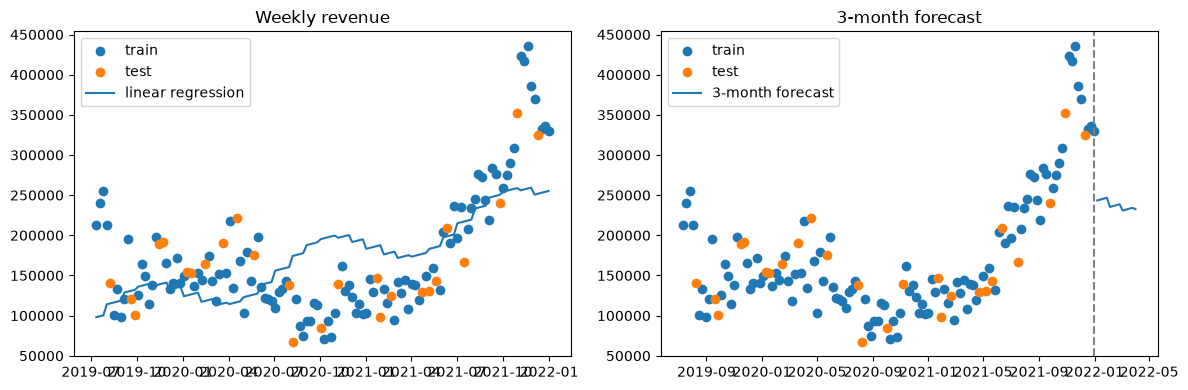

In [ ]:
fitted = pd.Series(
    revenue_scaler.inverse_transform(model.predict(X).reshape(-1, 1)).ravel(), #.ravel() is used to convert the 2D array returned by the inverse_transform method into a 1D array, which is more suitable for creating a pandas Series. This is necessary because the inverse_transform method returns a 2D array even if the input was a 1D array, and we want to have a 1D Series for easier plotting and analysis.
    index=X.index,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train.index, y_train, label="train")
axes[0].scatter(y_test.index, y_test, label="test")
axes[0].plot(fitted.index, fitted, label="linear regression")
axes[0].set_title("Weekly revenue")
axes[0].legend()

axes[1].scatter(y_train.index, y_train, label="train")
axes[1].scatter(y_test.index, y_test, label="test")
axes[1].plot(forecast_weekly.index, forecast_weekly, label="3-month forecast")
axes[1].axvline(LAST_DATE, color="grey", ls="--")
axes[1].set_title("3-month forecast")
axes[1].legend()

plt.tight_layout()
plt.show()


# Prophet

In [ ]:
from prophet import Prophet
import logging

logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").disabled = True

prophet_train = pd.DataFrame({"ds": y_train.index, "y": y_train.to_numpy()}) #no scaled data as Prophet automatically handles scaling internally. The "ds" column represents the dates (timestamps) of the observations, and the "y" column represents the corresponding target values (revenue). This DataFrame is used to train the Prophet model on the historical data.
prophet_model = Prophet(
    growth="linear",
    n_changepoints=12, # Number of potential changepoints to consider, purpose is to allow the model to adapt to changes in the trend of the data over time. By specifying a number of changepoints, the model can capture shifts in the underlying trend and improve its forecasting accuracy.
    changepoint_range=0.8, # The proportion of the history in which to place potential changepoints. For example, a value of 0.8 means that changepoints will be placed in the first 80% of the data, allowing the model to adapt to changes in the trend during that period while keeping the last 20% for validation and forecasting.
    yearly_seasonality=True, # Whether to include yearly seasonality in the model. purpose is to capture recurring patterns that occur on an annual basis, such as seasonal trends or events that affect the target variable. By enabling yearly seasonality, the model can learn and account for these patterns, improving its forecasting accuracy.
    weekly_seasonality=False, # Whether to include weekly seasonality in the model. purpose is to capture recurring patterns that occur on a weekly basis, such as day-of-week effects or weekly cycles in the data. By enabling weekly seasonality, the model can learn and account for these patterns, improving its forecasting accuracy.
    daily_seasonality=False, # Whether to include daily seasonality in the model. purpose is to capture recurring patterns that occur on a daily basis, such as day-of-week effects or daily cycles in the data. By enabling daily seasonality, the model can learn and account for these patterns, improving its forecasting accuracy.
    seasonality_mode="multiplicative", # Use multiplicative seasonality when seasonal swings grow with the level of revenue, which is common for sales data.
    changepoint_prior_scale=0.1, # Larger than Prophet's 0.05 default so the trend can bend more with the 2021 rise.
    seasonality_prior_scale=10.0,
    interval_width=0.8,
)
prophet_model.fit(prophet_train)
prophet_y_pred = prophet_model.predict(pd.DataFrame({"ds": y_test.index}))["yhat"].to_numpy()

print("MSE:", round(mean_squared_error(y_test, prophet_y_pred), 2))
print("R2:", round(r2_score(y_test, prophet_y_pred), 2))


MSE: 4434650496.65
R2: -0.07


In [ ]:
prophet_future = pd.DataFrame({
    "ds": pd.date_range(FORECAST_START, periods=forecast_weeks, freq="W-FRI")
})
prophet_forecast_weekly = (
    prophet_model.predict(prophet_future)
    .set_index("ds")["yhat"] #yhat is the predicted value of the target variable (revenue) for each date in the future. The set_index("ds") method sets the index of the resulting DataFrame to the "ds" column, which contains the dates for which predictions were made. This allows for easy alignment and comparison with the actual revenue data, as both will have the same date index.
    .clip(lower=0) # Ensure that the forecasted revenue is not negative
    .rename("ForecastRevenue")
)
print("Actual weekly revenue:")
print(weekly_revenue.round(0))
print("Prophet forecast:")
print(prophet_forecast_weekly.round(0))
print("3-month total:", round(prophet_forecast_weekly.sum(), 0))


Actual weekly revenue:
OrderDate
2019-07-12    212396.0
2019-07-19    240568.0
2019-07-26    254762.0
2019-08-02    212974.0
2019-08-09    141003.0
                ...   
2021-12-03    369301.0
2021-12-10    324842.0
2021-12-17    332327.0
2021-12-24    336319.0
2021-12-31    329824.0
Freq: W-FRI, Name: Revenue, Length: 130, dtype: float64
Prophet forecast:
ds
2022-01-07    363941.0
2022-01-14    373837.0
2022-01-21    383037.0
2022-01-28    396031.0
2022-02-04    412168.0
2022-02-11    423912.0
2022-02-18    423692.0
2022-02-25    413686.0
2022-03-04    407418.0
2022-03-11    418729.0
2022-03-18    447484.0
2022-03-25    477084.0
2022-04-01    488289.0
Name: ForecastRevenue, dtype: float64
3-month total: 5429307.0


# Visualize


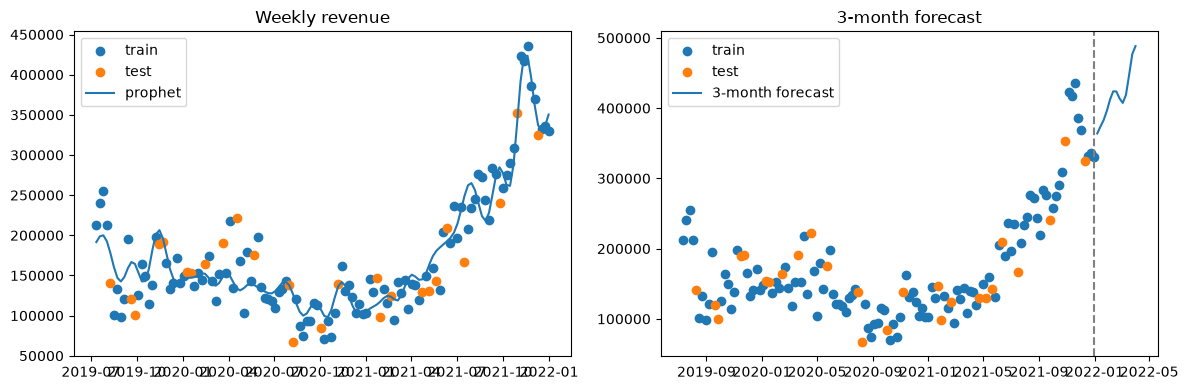

In [105]:
prophet_fitted = pd.Series(
    prophet_model.predict(pd.DataFrame({"ds": y.index}))["yhat"].to_numpy(),
    index=y.index,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train.index, y_train, label="train")
axes[0].scatter(y_test.index, y_test, label="test")
axes[0].plot(prophet_fitted.index, prophet_fitted, label="prophet")
axes[0].set_title("Weekly revenue")
axes[0].legend()

axes[1].scatter(y_train.index, y_train, label="train")
axes[1].scatter(y_test.index, y_test, label="test")
axes[1].plot(prophet_forecast_weekly.index, prophet_forecast_weekly, label="3-month forecast")
axes[1].axvline(LAST_DATE, color="grey", ls="--")
axes[1].set_title("3-month forecast")
axes[1].legend()

plt.tight_layout()
plt.show()


# Blend

In [106]:
blend_pred = (
    pd.Series(y_pred, index=y_test.index)
    + pd.Series(prophet_y_pred, index=y_test.index)
) / 2
blend_actual = y_test

print("MSE:", round(mean_squared_error(blend_actual, blend_pred), 2))
print("R2:", round(r2_score(blend_actual, blend_pred), 2))

MSE: 2811253724.24
R2: 0.32


In [ ]:
blend_forecast_weekly = ((forecast_weekly + prophet_forecast_weekly) / 2).clip(lower=0)

print(blend_forecast_weekly.round(0)) #.round(0) is used to round the forecasted revenue values to the nearest whole number for easier interpretation and presentation. This is particularly useful when dealing with revenue data, as it is often more meaningful to report whole dollar amounts rather than fractional values.
print("3-month total:", round(blend_forecast_weekly.sum(), 0))


2022-01-07    303661.0
2022-01-14    309176.0
2022-01-21    314345.0
2022-01-28    321409.0
2022-02-04    323713.0
2022-02-11    330153.0
2022-02-18    330611.0
2022-02-25    326176.0
2022-03-04    319129.0
2022-03-11    325352.0
2022-03-18    340298.0
2022-03-25    355666.0
2022-04-01    360408.0
Freq: W-FRI, Name: ForecastRevenue, dtype: float64
3-month total: 4260097.0


# Visualize

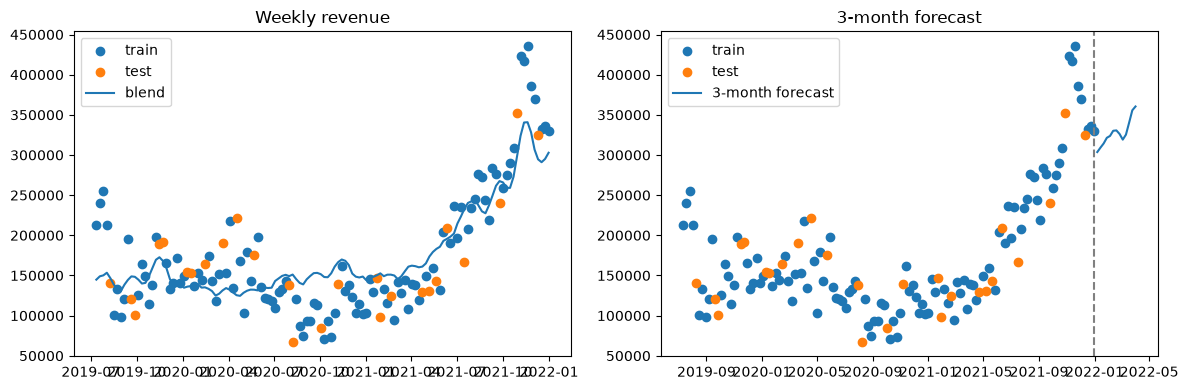

In [108]:
blend_fitted = (fitted + prophet_fitted) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train.index, y_train, label="train")
axes[0].scatter(blend_pred.index, blend_actual, label="test")
axes[0].plot(blend_fitted.index, blend_fitted, label="blend")
axes[0].set_title("Weekly revenue")
axes[0].legend()

axes[1].scatter(y_train.index, y_train, label="train")
axes[1].scatter(blend_pred.index, blend_actual, label="test")
axes[1].plot(blend_forecast_weekly.index, blend_forecast_weekly, label="3-month forecast")
axes[1].axvline(LAST_DATE, color="grey", ls="--")
axes[1].set_title("3-month forecast")
axes[1].legend()

plt.tight_layout()
plt.show()
